In [1]:
import numpy as np
import matplotlib.pyplot as plt
import celmech
from sympy import totient
from scipy.special import erfc

In [32]:
class NamouniMap():
    r"""
    A class representing the Namouni map. The map depends on parameters,
    :math:`K`, :math:`\phi`, :math:`\lambda`, and :math:`I`. The map is defined by the equations

    .. math::
        \begin{align}
        I_{n+1} &= I_n + W_\phi(I_{n+1},K_{n+1},\lambda_n,\phi_n) \\
        \phi_{n+1} &= \phi_n + W_\I(I_{n+1},K_{n+1},\lambda_n,\phi_n) \\
        K_{n+1} = I_{n+1}-I_n+K_n \\
        \lambda_{n+1} = \lambda_n + \frac{4\pi}{3\epsilon\sqrt{8K_{n+1}/3}}
        \end{align}



    See also Namouni et al. (1996)

    Parameters
    ----------
    m : float
        Planet-star mass ratio.
    e0 : float
        Initial eccentricity of the test particle
    a_r0 : float
        Initial relative semimajor axis in Hill's unit
    lambda0 : float
        Initial conjunction longitude
    phi0 : float
        Initial pericenter longf
    """
    #expansion coefficients

    
    def __init__(self,m,e0,a_r0,lambda0,phi0,ind,order):
        self._m = m
        self._e0 = e0
        self._a_r0 = a_r0
        self._lambda0 = lambda0
        self._phi0 = phi0
        self._ind = ind
        # self._Nmax = Nmax
        # self._y0 = y0
        # self._update_amplitudes()
        # self.mod = mod
        self._order = order

    @property
    def m(self):
        return self._m

    @property
    def e0(self):
        return self._e0

    @property
    def a_r0(self):
        return self._a_r0

    @property
    def lambda0(self):
        return self._lambda0

    @property
    def phi0(self):
        return self._phi0    

    @property
    def ind(self):
        return self._ind

    @property
    def order(self):
        return self._order
    
    @property
    def epsilon(self):
        m = self._m
        return (m/3)**(1/3) 

    @property
    def I0(self):
        e0 = self._e0
        return (e0/epsilon)**2/2

    @property
    def K0(self):
        a_r0 = self._a_r0
        return 3/8*a_r0**2
    
    # @J.setter
    # def J(self,value):
    #     self._J = value
    #     self.da0 = 2/3/self._J

    # @y0.setter
    # def y0(self,value):
    #     self._y0 = value
    #     self._update_amplitudes()

    # @Nmax.setter
    # def Nmax(self,value):
    #     self._Nmax = value
    #     self._update_amplitudes()

    # def _update_amplitudes(self):
    #     y0 = self._y0
    #     Nmax = self._Nmax
    #     self.amps = np.array([-4 * np.pi * k * sk(k,y0) / 3 for k in np.arange(1,Nmax+1)])

    # def f(self,theta):
    #     sin_ktheta = np.array([np.sin(k*theta) for k in range(1,self.Nmax+1)])
    #     return self.amps @ sin_ktheta

    # def dfdtheta_n(self,theta,n):
    #     trig = np.array([k**(n) * np.sin(k*theta + 0.5 * n * np.pi) for k in range(1,self.Nmax+1)])
    #     return self.amps @ trig


    def namouni_fo_step(self, In, Kn, phin, lambdan, arn, ind, exact_period):
        """First-order Namouni mapping step."""
        
        W101 = 3.359350011
        
        hn = np.sqrt(2*In)*np.cos(phin)
        kn = np.sqrt(2*In)*np.sin(phin)
        if ind == 1:
            hprime = hn + 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn - 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        else: #from DQT, the sign switches for the outer pair
            hprime = hn - 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn + 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
        #print(hn, kn)
        # both options should give the same result:
        Inprime = 1/2*(hprime**2 + kprime**2)
        #Inprime = In + 2*W1/arn**2*np.sqrt(2*In)*np.sin(thetan) + 2*W1**2/arn**4
        #Namouni update
        hnp1 = hprime
        knp1 = kprime
        Inp1 = Inprime
        Knp1 = Kn + Inp1 - In
        phinp1 = phiprime
        
        if exact_period==True:
            lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
        else:
            lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
        return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1


    def namouni_so_step(self, In, Kn, phin, lambdan, arn, ind, exact_period):
        """Second-order Namouni mapping step."""
        """The second order mapping involves an intermediate step and implicit scheme for eccentricity update."""
        """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
        W200= -1
        W101= 3.359350011
        W202= -2.678665722        
 
        hn = np.sqrt(2*In)*np.cos(phin)
        kn = np.sqrt(2*In)*np.sin(phin)
        if ind == 1:
            hprime = hn + 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn - 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        else: #from DQT, the sign switches for the outer pair
            hprime = hn - 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn + 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
        #thetaprime = (pomegaprime - lambdan)
        thetaprime = (phiprime - lambdan)
    
        # A = calc_coeff(2, W2, arn, thetaprime)
        # E1 = 1/(1+A)
        # Inp1 = E1*Inprime
        #implicit I update
        Iprime = 0.5*(hprime**2 + kprime**2)
        Inp1_prev = Iprime #first guess = Iprime
        while True: #iteratively update using implicit scheme
            Inp1_next = Iprime - 4*W202*np.sin(2*thetaprime)*2*Inp1_prev/arn**3
            if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12: #break when satisfied
                break
            Inp1_prev = Inp1_next
        # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
        Inp1 = Inp1_next
    
        #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
        phinp1 = phiprime - (W200 + 2*W202*np.cos(2*thetaprime))*2/arn**3
        Knp1 = Kn + Inp1 - In
        hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
        knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
        if exact_period==True:
            lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
        else:
            lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
        return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1



    def namouni_4o_step(self, In, Kn, phin, lambdan, arn, ind, exact_period):
        """Fourth-order Namouni mapping step."""
        """The fourth order mapping involves an intermediate step and implicit scheme for eccentricity update."""
        """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
        W200, W400= -1,-3/8
        W101, W301 = 3.359350011, 0.1430675142
        W202, W402 = -2.678665722, 0.5232506456
        W303 = 2.639498803
        W404 = -2.855951527
        hn = np.sqrt(2*In)*np.cos(phin)
        kn = np.sqrt(2*In)*np.sin(phin)
        if ind == 1:
            hprime = hn + 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn - 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        else: #from DQT, the sign switches for the outer pair
            hprime = hn - 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn + 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
        #thetaprime = (pomegaprime - lambdan)
        thetaprime = (phiprime - lambdan)
    
        # A = calc_coeff(2, W2, arn, thetaprime)
        # E1 = 1/(1+A)
        # Inp1 = E1*Inprime
        #implicit I update
        Iprime = 0.5*(hprime**2 + kprime**2)
        Inp1_prev = Iprime #first guess = Iprime
        phinp1_prev = phiprime
        while True: #iteratively update using implicit scheme
            Inp1o2 = 4*W202*np.sin(2*thetaprime)*2*Inp1_prev/arn**3
            Inp1o3 = (2*W301*np.sin(thetaprime)+6*W303*np.sin(3*thetaprime))*(2*Inp1_prev)**(3/2)/arn**4
            Inp1o4 = (4*W402*np.sin(2*thetaprime)+8*W404*np.sin(4*thetaprime))*(2*Inp1_prev)**(2)/arn**5
            Inp1_next = Iprime - Inp1o2 - Inp1o3 - Inp1o4
            phinp1o2 = (W200 + 2*W202*np.cos(2*thetaprime))*2/arn**3
            phinp1o3 = 3*2**(3/2)*(W301*np.cos(thetaprime)+W303*np.cos(3*thetaprime))*Inp1_prev**0.5/arn**4
            phinp1o4 = 8*(W400+2*W402*np.cos(2*thetaprime)+2*W404*np.cos(4*thetaprime))*Inp1_prev/arn**5
            phinp1_next = phiprime - (phinp1o2+phinp1o3+phinp1o4)
            if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12 and np.abs((phinp1_next-phinp1_prev)/phinp1_next) < 1e-12: 
                #break when satisfied
                break
            Inp1_prev = Inp1_next
            phinp1_prev = phinp1_next
        # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
        Inp1 = Inp1_next
        phinp1 = phinp1_next
        #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
        Knp1 = Kn + Inp1 - In
        hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
        knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
        if exact_period==True:
            lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
        else:
            lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
        return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

    def namouni_10o_step(self, In, Kn, phin, lambdan, arn, ind, exact_period):
        """Tenth-order Namouni mapping step."""
        """The tenth order mapping involves an intermediate step and implicit scheme for eccentricity update."""
        """This calculates the implicit update iteratively instead of explicitly solving for the next value."""
        #define all coeffs in here so that we won't get confused
        #format WABC = W^{A,B}_C
        W200, W400, W600, W800, W1000 = -1,-3/8,-5/24,-35/256,-63/640
        W101, W301, W501, W701, W901 = 3.359350011, 0.1430675142, 0.2652528982, 0.1598760057, 0.1125398541
        W202, W402, W602, W802, W1002 = -2.678665722, 0.5232506456, -0.2880525893, -0.1146109541, -0.09264257446
        W303, W503, W703, W903 = 2.639498803, -1.270297850, 0.5079066956, 0.04027194541
        W404, W604, W804, W1004 = -2.855951527, 2.244981532, -1.030263325, 0.1370220235
        W505, W705, W905 = 3.259400253, -3.586274249, 2.034584646
        W606, W806, W1006 = -3.850815349, 5.467708834, -3.807558748
        W707, W907 = 4.661571101, -8.124434579
        W808, W1008 = -5.745863967, 11.88290720
        W909 = 7.181868977
        W10010 = -9.077037610
        hn = np.sqrt(2*In)*np.cos(phin)
        kn = np.sqrt(2*In)*np.sin(phin)
        if ind == 1:
            hprime = hn + 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn - 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        else: #from DQT, the sign switches for the outer pair
            hprime = hn - 2*W101*np.sin(lambdan)/arn**2 # + for Namouni, - for pomega
            kprime = kn + 2*W101*np.cos(lambdan)/arn**2 # - for Namouni, + for pomega
        phiprime = np.arctan2(kprime, hprime) # 4 quadrant arctan
        #thetaprime = (pomegaprime - lambdan)
        thetaprime = (phiprime - lambdan)
    
        # A = calc_coeff(2, W2, arn, thetaprime)
        # E1 = 1/(1+A)
        # Inp1 = E1*Inprime
        #implicit I update
        Iprime = 0.5*(hprime**2 + kprime**2)
        Inp1_prev = Iprime #first guess = Iprime
        phinp1_prev = phiprime
        while True: #iteratively update using implicit scheme
            print("prev value of I: ",Inp1_prev)
            Inp1o1 = 2*(W301/arn**4*(2*Inp1_prev)**1.5+W501/arn**6*(2*Inp1_prev)**2.5+W701/arn**8*(2*Inp1_prev)**3.5+W901/arn**10*(2*Inp1_prev)**4.5)*np.sin(thetaprime)
            Inp1o2 = 4*(W202/arn**3*(2*Inp1_prev)+W402/arn**5*(2*Inp1_prev)**2+W602/arn**7*(2*Inp1_prev)**3+W802/arn**9*(2*Inp1_prev)**4+W1002/arn**11*(2*Inp1_prev)**5)*np.sin(2*thetaprime)
            Inp1o3 = 6*(W303/arn**4*(2*Inp1_prev)**1.5+W503/arn**6*(2*Inp1_prev)**2.5+W703/arn**8*(2*Inp1_prev)**3.5+W903/arn**10*(2*Inp1_prev)**4.5)*np.sin(3*thetaprime)
            Inp1o4 = 8*(W404/arn**5*(2*Inp1_prev)**2+W604/arn**7*(2*Inp1_prev)**3+W804/arn**9*(2*Inp1_prev)**4+W1004/arn**11*(2*Inp1_prev)**5)*np.sin(4*thetaprime)
            Inp1o5 = 10*(W505/arn**6*(2*Inp1_prev)**2.5+W705/arn**8*(2*Inp1_prev)**3.5+W905/arn**10*(2*Inp1_prev)**4.5)*np.sin(5*thetaprime)
            Inp1o6 = 12*(W606/arn**7*(2*Inp1_prev)**3+W806/arn**9*(2*Inp1_prev)**4+W1006/arn**11*(2*Inp1_prev)**5)*np.sin(6*thetaprime)
            Inp1o7 = 14*(W707/arn**8*(2*Inp1_prev)**3.5+W907/arn**10*(2*Inp1_prev)**4.5)*np.sin(7*thetaprime)
            Inp1o8 = 16*(W808/arn**9*(2*Inp1_prev)**4+W1008/arn**11*(2*Inp1_prev)**5)*np.sin(8*thetaprime)
            Inp1o9 = 18*(W909/arn**10*(2*Inp1_prev)**4.5)*np.sin(9*thetaprime)
            Inp1o10 = 20*(W10010/arn**11*(2*Inp1_prev)**5)*np.sin(10*thetaprime)
    
            Inp1_next = Iprime -Inp1o2-Inp1o3-Inp1o4-Inp1o5-Inp1o6-Inp1o7-Inp1o8-Inp1o9-Inp1o10
            phinp1o0 = W200*2/arn**3+W400*2**2*2*Inp1_prev/arn**5+W600*2**3*3*Inp1_prev**2/arn**7+W800*2**4*4*Inp1_prev**3/arn**9+W1000*2**5*5*Inp1_prev**4/arn**11
            phinp1o1 = 2*(W301*2**1.5*1.5*Inp1_prev**0.5/arn**4+W501*2**2.5*2.5*Inp1_prev**1.5/arn**6+W701*2**3.5*3.5*Inp1_prev**2.5/arn**8+W901*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(thetaprime)
            phinp1o2 = 2*(W202*2/arn**3+W402*2**2*2*Inp1_prev/arn**5+W602*2**3*3*Inp1_prev**2/arn**7+W802*2**4*4*Inp1_prev**3/arn**9+W1002*2**5*5*Inp1_prev**4/arn**11)*np.cos(2*thetaprime)
            phinp1o3 = 2*(W303*2**1.5*1.5*Inp1_prev**0.5/arn**4+W503*2**2.5*2.5*Inp1_prev**1.5/arn**6+W703*2**3.5*3.5*Inp1_prev**2.5/arn**8+W903*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(3*thetaprime)
            phinp1o4 = 2*(W404*2**2*2*Inp1_prev/arn**5+W604*2**3*3*Inp1_prev**2/arn**7+W804*2**4*4*Inp1_prev**3/arn**9+W1004*2**5*5*Inp1_prev**4/arn**11)*np.cos(4*thetaprime)
            phinp1o5 = 2*(W505*2**2.5*2.5*Inp1_prev**1.5/arn**6+W705*2**3.5*3.5*Inp1_prev**2.5/arn**8+W905*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(5*thetaprime)
            phinp1o6 = 2*(W606*2**3*3*Inp1_prev**2/arn**7+W806*2**4*4*Inp1_prev**3/arn**9+W1006*2**5*5*Inp1_prev**4/arn**11)*np.cos(6*thetaprime)
            phinp1o7 = 2*(W707*2**3.5*3.5*Inp1_prev**2.5/arn**8+W907*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(7*thetaprime)
            phinp1o8 = 2*(W808*2**4*4*Inp1_prev**3/arn**9+W1008*2**5*5*Inp1_prev**4/arn**11)*np.cos(8*thetaprime)
            phinp1o9 = 2*(W909*2**4.5*4.5*Inp1_prev**3.5/arn**10)*np.cos(9*thetaprime)
            phinp1o10 = 2*(W10010*2**5*5*Inp1_prev**4/arn**11)*np.cos(10*thetaprime)
            phinp1_next = phiprime-phinp1o0-phinp1o1-phinp1o2-phinp1o3-phinp1o4-phinp1o5-phinp1o6-phinp1o7-phinp1o8-phinp1o9-phinp1o10
            
            print("error: ",np.abs((Inp1_next-Inp1_prev)/Inp1_next))
            
            if np.abs((Inp1_next-Inp1_prev)/Inp1_next) < 1e-12 and np.abs((phinp1_next-phinp1_prev)/phinp1_next) < 1e-12: 
                #break when satisfied
                break
            Inp1_prev = Inp1_next
            phinp1_prev = phinp1_next
        # Inp1 = (0.5*(hprime**2 + kprime**2)) / (1 + 4*W2*np.sin(2*thetaprime)*2/arn**3)
        Inp1 = Inp1_next
        phinp1 = phinp1_next
        #pomeganp1 = pomegaprime - (W200 + 2*W2*np.cos(2*thetaprime))*2/arn**3
        Knp1 = Kn + Inp1 - In
        hnp1 = np.sqrt(2*Inp1)*np.cos(phinp1)
        knp1 = np.sqrt(2*Inp1)*np.sin(phinp1)
        if exact_period==True:
            lambdanp1 = lambdan + 2*np.pi*np.abs(1/((1+np.sqrt(8*Knp1/3)*epsilon)**(-3/2)-1)) #same lambda
        else:
            lambdanp1 = lambdan + 4*np.pi/(3*epsilon*np.sqrt(8*Knp1/3))
        return Inp1, Knp1, phinp1, lambdanp1, hnp1, knp1

        #This function runs Namouni mapping for multiple conjunctions
    def runmap(self, I0, K0, phi0, lambda0, Nconj, order, exact_period):
        try:                # minimize function later passes a 1-element list, so make it work for both scalar and list
            K0 = K0[0]
        except:
            pass
        Is, Ks, phis, lambdas, hs, ks = np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1), np.zeros(Nconj+1)
        Is[0] = I0
        Ks[0] = K0
        phis[0] = phi0
        lambdas[0] = lambda0
        ar0 = np.sqrt(8*K0/3)
        
        for i in range(Nconj):
            if order==1:
                Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = self.namouni_fo_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind, exact_period)
            elif order==2:
                Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = self.namouni_so_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind, exact_period)
            elif order==4:
                Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = self.namouni_4o_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind, exact_period)
            elif order==10:
                Is[i+1], Ks[i+1], phis[i+1], lambdas[i+1], hs[i+1], ks[i+1] = self.namouni_10o_step(Is[i], Ks[i], phis[i], lambdas[i], ar0, ind, exact_period)
        return Is, Ks, phis, lambdas, hs, ks
    
    def __call__(self,X,Nconj,order,exact_period=True):
        I0, K0, phi0, lambda0 = X
        epsilon = self.epsilon
        # x1 = x + eps * self.f(theta)
        # theta1 = theta - 2 * np.pi * x1
        # theta1 = self._modfn(theta1)
    
        Is, Ks, phis, lambdas, hs, ks = self.runmap(I0, K0, phi0, lambda0, Nconj, order, exact_period)
        return Is, Ks, phis, lambdas, hs, ks


In [ ]:
from celmech.maps import CometMap

In [ ]:
comet_map = CometMap(m=5e-5, q=4/3, N=20, max_kmax=32, rtol=0.05, atol=1e-8, mod=True)

In [ ]:
comet_map

In [ ]:
comet_map.D_QL()

In [3]:
from celmech.maps import EncounterMap

In [5]:
enc_map = EncounterMap(m=5e-5,J=5,y0 = 0.5)

In [15]:
IC = (0.433, 13)
enc_result = enc_map(IC)

In [16]:
enc_result

array([ 0.30592809, 13.02022412])

In [17]:
enc_result = enc_map(enc_result)
enc_result

array([ 0.0578981, 13.0394752])

In [6]:
theta0=2.1
x0_arr = np.linspace(11,15.5,30)
epsilon = 5e-3
m = 3*epsilon**3
J = 13 #J:J-1 resonance
a1 = 1
a2 = 13*epsilon*a1 + a1
ecross = (a2-a1)/a1
ecc = 7*epsilon
y0 = ecc/ecross
enc_map = EncounterMap(m=m, J=J, y0=y0, Nmax=10, mod=True)
Nruns = 1000
#print(enc_map)

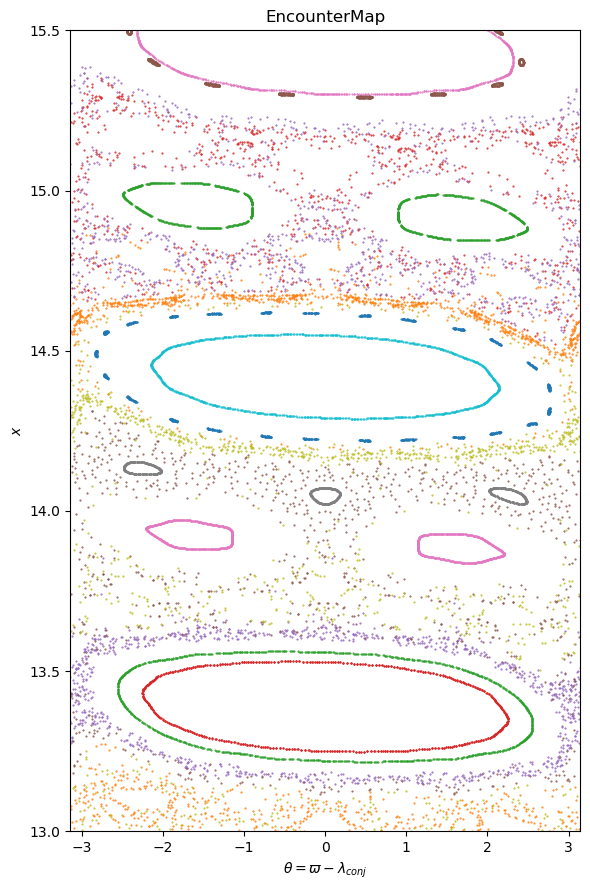

In [7]:
x_results = np.zeros((len(x0_arr),Nruns+1))
theta_results = np.zeros((len(x0_arr),Nruns+1))
fig, ax = plt.subplots(figsize=(6,9))
for i in range(len(x0_arr)):
    IC0 = (theta0, x0_arr[i])
    for j in range(Nruns):
        result = enc_map(IC0)
        theta_results[i,j], x_results[i,j] = result
        IC0 = result
    theta_results[i,:] = (theta_results[i,:]+np.pi)%(2*np.pi)-np.pi
    ax.plot(theta_results[i,:], x_results[i,:]*1.03, '.', markersize=1)
        


ax.set_xlabel(r'$\theta = \varpi- \lambda_{conj}$') 
ax.set_ylabel('$x$')
ax.set_title('EncounterMap')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(13,15.5)
#ax.axvline(.0026987345)
fig.tight_layout()
#print((thetas[1:]-thetas[:-1])/np.pi)
#fig.savefig('encountermap_cateye.png')

NamouniMap class test cell -- plotting a surface of section

24.500000000000007


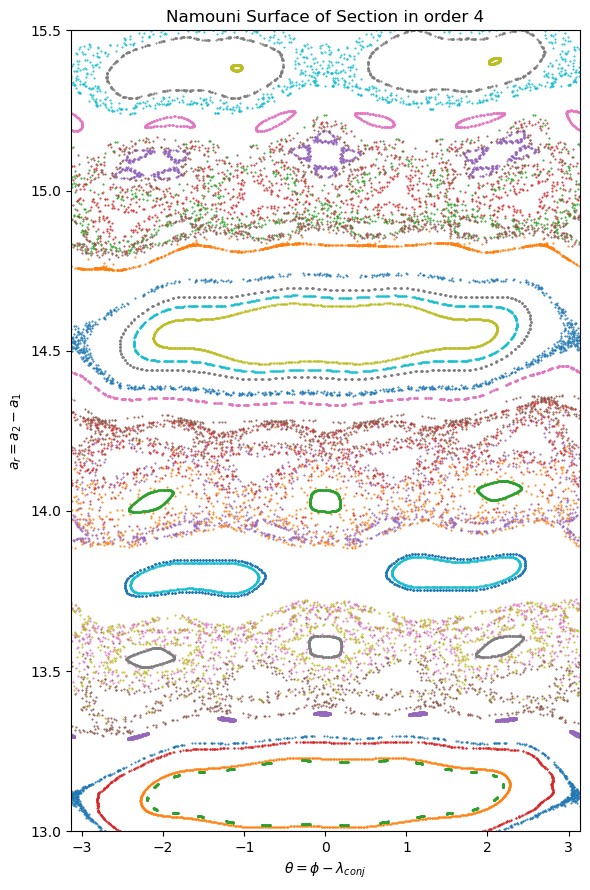

In [50]:
ind = 1
order = 4
a_r0 = 13
lambda0 = 0
phi0 = 2.1
e0 = 7*epsilon

ar0_list = np.linspace(13, 15.5, 30) 
#ar0_list = np.linspace(13.33447880751,  15.5, Na) # list of a = a2-a1 values
K0_list = 3/8*ar0_list**2
I0 = (e0/epsilon)**2/2
# print(I0)
C = K0_list[0]-I0 # conserved quantity
I_list = K0_list - C #for the same conserved quantity
e0_list = np.sqrt(2*I_list)*epsilon
Nconj = 1000

ar_conj = np.zeros((len(ar0_list), Nconj+1))
theta_conj = np.zeros((len(ar0_list), Nconj+1))
K_conj = np.zeros((len(ar0_list), Nconj+1))
I_conj = np.zeros((len(ar0_list), Nconj+1))

for i, ar in enumerate(ar0_list):
    e0 = e0_list[i]
    n_map = NamouniMap(m,e0,ar,lambda0,phi0,ind,order)
    I0 = n_map.I0
    K0 = n_map.K0
    #print(e0)
    # initial conditions
    #integrating
    IC = (I0,K0,phi0,lambda0)
    Is, Ks, phis, lambdas, hs, ks = n_map(IC,Nconj,order,exact_period=True)
    thetas = (phis-lambdas+np.pi) % (2*np.pi) - np.pi
    #thetas = np.where(thetas>np.pi, thetas - 2*np.pi, thetas)
    ar_conj[i,:] = np.sqrt(8/3*Ks)
    theta_conj[i,:] = thetas
    I_conj[i,:] = Is
    K_conj[i,:] = Ks
        
#  plot
acol = ar0_list.reshape((30, -1)) # column vector
a_arr = np.tile(acol, Nconj)
fig, ax = plt.subplots(figsize=(6,9))
ax.plot(theta_conj.T, ar_conj.T, '.', markersize=1)
ax.set_xlabel(r'$\theta = \phi- \lambda_{conj}$') 
ax.set_ylabel('$a_r = a_2 - a_1$')
ax.set_title(f'Namouni Surface of Section in order {order}')
# ax.set_xlim(-np.pi, np.pi)
ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(13,15.5)
#ax.set_ylim(13.33447880751,  15.5)
#ax.axvline(.0026987345)
fig.tight_layout()